In [4]:
#Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
import pandas as pd

avgtemp = pd.read_csv(
    r"D:\SET\Crop-yield-prediction-using-weather-data-and-NDVI-time-series-main\Phase1\csv\AverageTemperature\avgtemp.csv"
)

avgtemp.head()


,Year,Month,avgtemp_past,avgtemp_pasttopast,avgtemp
0,2002,1,16.85,18.46,17.89
1,2002,2,20.22,17.85,16.60
2,2002,3,18.30,19.64,18.02
3,2002,4,14.86,17.75,16.72
4,2002,5,15.28,13.03,14.20


In [6]:
avgtemp

,Year,Month,avgtemp_past,avgtemp_pasttopast,avgtemp
0,2002,1,16.85,18.46,17.89
1,2002,2,20.22,17.85,16.60
2,2002,3,18.30,19.64,18.02
3,2002,4,14.86,17.75,16.72
4,2002,5,15.28,13.03,14.20
...,...,...,...,...,...
211,2019,8,8.12,8.78,8.78
212,2019,9,10.91,8.60,8.60
213,2019,10,13.51,10.03,10.03
214,2019,11,14.70,14.19,14.19


In [7]:
avgtemp.shape

(216, 5)

In [8]:
avgtemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                216 non-null    int64  
 1   Month               216 non-null    int64  
 2   avgtemp_past        216 non-null    float64
 3   avgtemp_pasttopast  216 non-null    float64
 4   avgtemp             216 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 8.6 KB


In [9]:
#Creating correlation matrix for precipitation
corr_matrix=avgtemp.corr()
corr_matrix

,Year,Month,avgtemp_past,avgtemp_pasttopast,avgtemp
Year,1.000000e+00,4.861859e-15,-0.012342,-0.032402,0.002503
Month,4.861859e-15,1.000000e+00,-0.437231,-0.435343,-0.444344
avgtemp_past,-1.234195e-02,-4.372307e-01,1.000000,0.921491,0.920216
avgtemp_pasttopast,-3.240248e-02,-4.353428e-01,0.921491,1.000000,0.933440
avgtemp,2.502547e-03,-4.443439e-01,0.920216,0.933440,1.000000


In [10]:
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

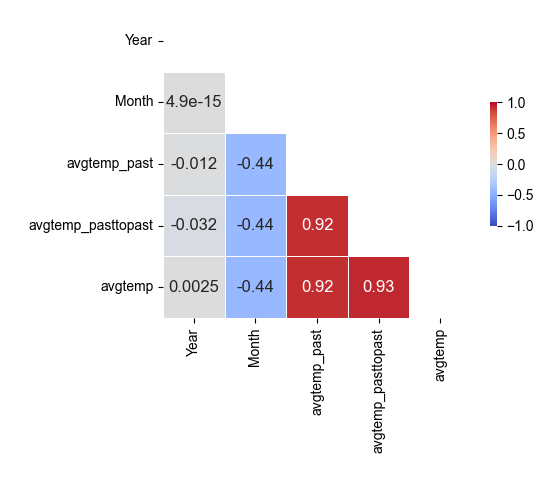

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure and axes
f, ax = plt.subplots(figsize=(5, 4)) 

# Generate the heatmap
heatmap = sns.heatmap(corr_matrix, mask=mask, square=True, linewidths=.5, 
                      cmap='coolwarm', cbar_kws={'shrink': .4, 'ticks': [-1, -.5, 0, 0.5, 1]},
                      vmin=-1, vmax=1, annot=True, annot_kws={'size': 12})

# Add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation=0)
ax.set_xticklabels(corr_matrix.columns)

# Set the style to show ticks
sns.set_style("white", {'xtick.bottom': True, 'ytick.left': True})

plt.show()

In [12]:
avgtemp=avgtemp.drop(['Year','Month'],axis=1)

In [13]:
avgtemp.shape

(216, 3)

In [14]:
X=avgtemp.drop('avgtemp',axis=1)
y=avgtemp.avgtemp

In [15]:
X

,avgtemp_past,avgtemp_pasttopast
0,16.85,18.46
1,20.22,17.85
2,18.30,19.64
3,14.86,17.75
4,15.28,13.03
...,...,...
211,8.12,8.78
212,10.91,8.60
213,13.51,10.03
214,14.70,14.19


In [16]:
y

0      17.89
1      16.60
2      18.02
3      16.72
4      14.20
       ...  
211     8.78
212     8.60
213    10.03
214    14.19
215    14.96
Name: avgtemp, Length: 216, dtype: float64

In [17]:
X.shape

(216, 2)

In [18]:
y.shape

(216,)

In [19]:
#Creating Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [20]:
X_train,y_train=np.array(X_train),np.array(y_train)

### Linear Regressor

In [21]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

In [22]:
li=LinearRegression()

In [23]:
li.fit(X_train,y_train)

LinearRegression()

In [24]:
#Prediction of values
Lir_ypred= li.predict(X_test)
Lir_ypred

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([16.47398943,  6.79206524, 10.50365241, 17.78873834, 17.81822148,
       12.37611495, 16.93412529,  7.81480162,  8.83353309,  9.65082215,
       11.00822127,  8.44399542, 11.83382044, 17.07348237,  9.72716317,
       17.59538832, 16.35221708, 16.11384847,  7.68847644, 15.57420765,
       14.53091374,  9.37479548])

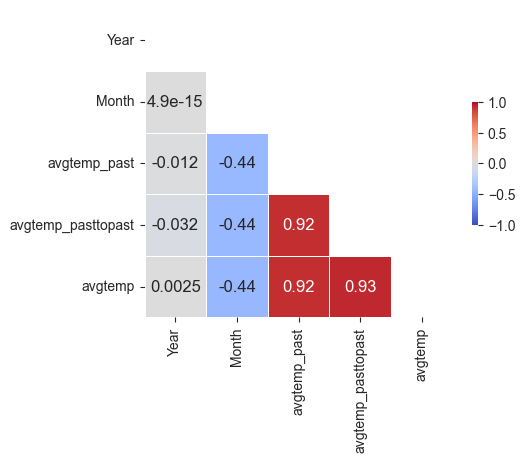

Mean Absolute Error: 1.0787921021306004
Mean squared Error: 1.741969884960456
Root Mean Squared Error: 1.3198370675808646
R2 Score: 0.8807783388535537


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 1. Correlation Matrix and Masking ---
# Fixed: Used 'bool' instead of 'np.bool' to avoid AttributeError
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# --- 2. Heatmap Visualization ---
# Fixed: Ensure 'plt' and 'sns' are imported before calling
f, ax = plt.subplots(figsize=(5, 4)) 

heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    square=True, 
    linewidths=.5, 
    cmap='coolwarm', 
    cbar_kws={'shrink': .4, 'ticks': [-1, -.5, 0, 0.5, 1]},
    vmin=-1, 
    vmax=1, 
    annot=True, 
    annot_kws={'size': 12}
)

# Add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation=0)
ax.set_xticklabels(corr_matrix.columns)

# Fixed: sns.set_style requires a valid style name (e.g., "white")
sns.set_style("white", {'xtick.bottom': True, 'ytick.left': True})
plt.show()

# --- 3. Model Evaluation ---
# Fixed: Ensure 'mean_squared_error' is imported from sklearn.metrics
print('Mean Absolute Error:', mean_absolute_error(y_test, Lir_ypred))
print('Mean squared Error:', mean_squared_error(y_test, Lir_ypred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, Lir_ypred)))
print('R2 Score:', r2_score(y_test, Lir_ypred))

In [26]:
linear_r2_score=r2_score(y_test,Lir_ypred)
linear_r2_score

0.8807783388535537

### Lasso Regressor

In [27]:
#Lasso Regressor
lass=Lasso(alpha=0.0001)
lass.fit(X_train,y_train)

Lasso(alpha=0.0001)

In [28]:
Lass_ypred= lass.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [29]:
print('Mean squared Error:',mean_squared_error(y_test,Lass_ypred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,Lass_ypred)))
#print('R2_Score:',r2_score(y_test,Lass_ypred))

Mean squared Error: 1.741899134953121
Root Mean Squared Error: 1.3198102647551735


In [30]:
lasso_r2_score=r2_score(y_test,Lass_ypred)
lasso_r2_score

0.8807831810345085

### Ridge Regressor

In [31]:
#RIdge
rid=Ridge(alpha=0.0001)
rid.fit(X_train,y_train)

Ridge(alpha=0.0001)

In [32]:
rid_ypred= rid.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


In [33]:
print('Mean squared Error:',mean_squared_error(y_test,rid_ypred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,rid_ypred)))
#print('R2_Score:',r2_score(y_test,rid_ypred))

Mean squared Error: 1.7419698362920186
Root Mean Squared Error: 1.3198370491435747


In [34]:
ridge_r2_score=r2_score(y_test,rid_ypred)
ridge_r2_score

0.8807783421844563

### Decision Tree Regressor

In [35]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()

In [36]:
dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [37]:
dt_ypred= dt.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [38]:
print('Mean squared Error:',mean_squared_error(y_test,dt_ypred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,dt_ypred)))
#print('R2_Score:',r2_score(y_test,dt_ypred))

Mean squared Error: 3.5387590909090902
Root Mean Squared Error: 1.8811589754481386


In [39]:
decisiontree_r2_score=r2_score(y_test,dt_ypred)
decisiontree_r2_score

0.7578048042863571

### KNeighbour Regressor

In [40]:
from sklearn.neighbors import KNeighborsRegressor

kn=KNeighborsRegressor(n_neighbors=14)
kn.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=14)

In [41]:
kn1_pred=kn.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


In [42]:
print('Mean squared Error:',mean_squared_error(y_test,kn1_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,kn1_pred)))
#print('R2_Score:',r2_score(y_test,kn1_pred))

Mean squared Error: 1.6402280148423019
Root Mean Squared Error: 1.280713869231649


In [43]:
kneighbour_r2_score=r2_score(y_test,kn1_pred)
kneighbour_r2_score

0.887741624997796

### SVR Regressor

In [44]:
from sklearn.svm import SVR
svr=SVR(kernel='rbf')
svr.fit(X_train,y_train)
svr_pred=svr.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


In [45]:
print('Mean squared Error:',mean_squared_error(y_test,svr_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,svr_pred)))
#print('R2_Score:',r2_score(y_test,svr_pred))

Mean squared Error: 1.646794809512616
Root Mean Squared Error: 1.283275032684972


In [46]:
svr_r2_score=r2_score(y_test,svr_pred)
svr_r2_score

0.8872921888876991

### Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf = RandomForestRegressor(n_estimators = 1000, random_state = 42)
rf.fit(X_train, y_train);

In [49]:
rf_pred=rf.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [50]:
print('Mean squared Error:',mean_squared_error(y_test,rf_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,rf_pred)))
#print('R2_Score:',r2_score(y_test,rf_pred))

Mean squared Error: 1.9720438881454563
Root Mean Squared Error: 1.4042948010106198


In [51]:
randomforest_r2_score=r2_score(y_test,rf_pred)
randomforest_r2_score

0.8650319100070234

### Bayes Regressor

In [52]:
from sklearn.linear_model import BayesianRidge
br=BayesianRidge()
br.fit(X_train,y_train)

BayesianRidge()

In [53]:
br_pred=br.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but BayesianRidge was fitted without feature names
  warnings.warn(


In [54]:
print('Mean squared Error:',mean_squared_error(y_test,br_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,br_pred)))
print('R2_Score:',r2_score(y_test,br_pred))

Mean squared Error: 1.7388230254956312
Root Mean Squared Error: 1.3186443893239872
R2_Score: 0.8809937121593898


In [55]:
bayes_r2_score=r2_score(y_test,br_pred)
bayes_r2_score

0.8809937121593898

In [56]:
Regressors=['Linear','Lasso','Ridge','DecisionTree','KNeighbour','SVR','RandomForest','Bayesian']
R2_Score=[linear_r2_score,lasso_r2_score,ridge_r2_score,decisiontree_r2_score,kneighbour_r2_score,svr_r2_score,randomforest_r2_score,bayes_r2_score]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


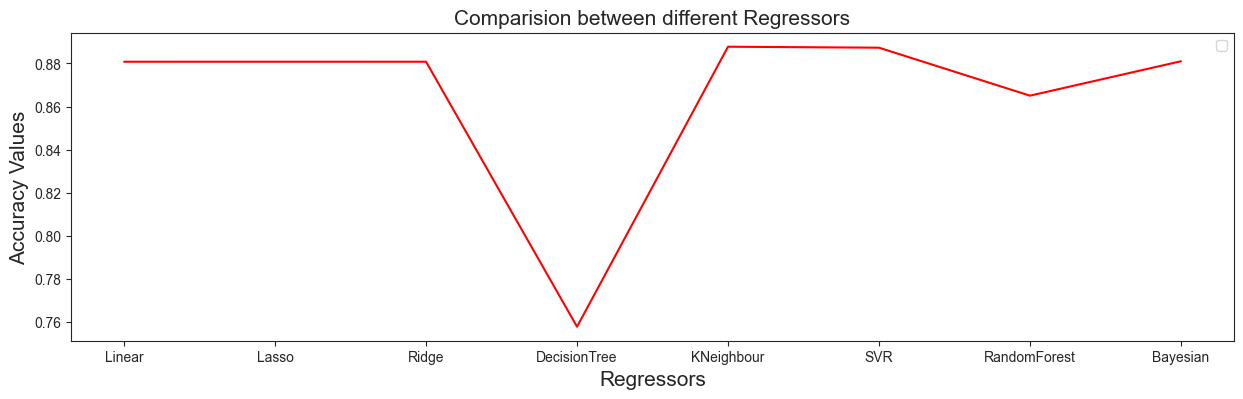

In [57]:
plt.figure(figsize=(15,4))
plt.plot(Regressors,R2_Score, color = 'Red')

plt.title('Comparision between different Regressors',fontsize=15)
plt.xlabel('Regressors',fontsize=15)
plt.ylabel('Accuracy Values',fontsize=15)
plt.legend()
plt.show()


## KNeighbour Regressor is sutaible for Average Temperature with accuracy of 89.72% followed by Bayesian Regressor with accuracy of 88.03%

In [60]:
avgtemp2020 = pd.read_csv("D:/SET/Crop-yield-prediction-using-weather-data-and-NDVI-time-series-main/Phase1/csv/AverageTemperature/avgtemp2020.csv")

In [61]:
avgtemp2020=avgtemp2020.drop(['Year','Month'],axis=1)

In [62]:
avgetemp2020=avgtemp2020.iloc[:,:].values

In [63]:
avgtemp2020

,avgtemp_past,avgtemp_pasttopast
0,17.27,16.97
1,18.52,16.52
2,18.47,16.26
3,19.05,16.79
4,15.40,15.34
5,9.39,8.35
6,8.10,7.48
7,8.78,8.12
8,8.60,10.91
9,10.03,13.51


In [64]:
avgtemp2020_pred=[]

In [65]:
#Using Kneighbour regressor for prediction
avgtemp2020_pred=kn.predict(avgtemp2020)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


In [66]:
avgtemp2020_pred

array([17.59071429, 17.07      , 17.12      , 17.35785714, 15.75785714,
        8.80071429,  7.90285714,  8.60214286,  9.89714286, 11.55785714,
       15.06      , 15.58428571])

In [67]:
#Predicting for 2020
avgtemp_data=pd.DataFrame(data=avgtemp2020_pred)
avgtemp_data

,0
0,17.590714
1,17.070000
2,17.120000
3,17.357857
4,15.757857
5,8.800714
6,7.902857
7,8.602143
8,9.897143
9,11.557857


In [68]:
#Exporting the predictions of 2020 into csv file
avgtemp_data.to_csv(r"D:\SET\Crop-yield-prediction-using-weather-data-and-NDVI-time-series-main\Phase1\csv\AverageTemperature\2020avgtemp.csv")
